In [1]:
# ✅ Install necessary dependencies
!pip install opencv-python-headless soundfile
!pip install torch torchaudio tensorflow tqdm

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchaudio
import torchaudio.transforms as T
import soundfile as sf
import cv2
import random
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:

torchaudio.set_audio_backend("soundfile")


SUPPORTED_FORMATS = ('.wav', '.flac', '.mp3', '.ogg', '.m4a', '.aac', '.wma')

def load_audio_file(file_path, sr=16000):
    """Loads an audio file and resamples if needed."""
    try:
        waveform, sample_rate = torchaudio.load(file_path)
        waveform = waveform.to(dtype=torch.float32)
        
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sample_rate != sr:
            resampler = T.Resample(orig_freq=sample_rate, new_freq=sr)
            waveform = resampler(waveform)

        return waveform.squeeze(0), sr

    except Exception:
        try:
            waveform, sample_rate = sf.read(file_path, always_2d=True, dtype='float32')
            waveform = torch.tensor(waveform[:, 0], dtype=torch.float32)

            if sample_rate != sr:
                resampler = T.Resample(orig_freq=sample_rate, new_freq=sr)
                waveform = resampler(waveform)

            return waveform, sr
        except:
            return None, None

def load_data_from_folders(real_folder, fake_folder, sr=22050):
    """Loads real and fake audio data from folders and assigns labels."""
    real_data, fake_data, labels = [], [], []

    real_files = [f for f in os.listdir(real_folder) if f.lower().endswith(SUPPORTED_FORMATS)]
    fake_files = [f for f in os.listdir(fake_folder) if f.lower().endswith(SUPPORTED_FORMATS)]

    for file_name in tqdm(real_files, desc="🔹 Loading Real Files"):
        audio_data, _ = load_audio_file(os.path.join(real_folder, file_name), sr=sr)
        if audio_data is not None:
            real_data.append(audio_data)
            labels.append(1)  # Real label

    for file_name in tqdm(fake_files, desc="🔹 Loading Fake Files"):
        audio_data, _ = load_audio_file(os.path.join(fake_folder, file_name), sr=sr)
        if audio_data is not None:
            fake_data.append(audio_data)
            labels.append(0)  # Fake label

    return real_data, fake_data, labels

# ✅ Load Data
real_data, fake_data, labels = load_data_from_folders(
    "D:/datasets/deepfake_audio/real",  
    "D:/datasets/deepfake_audio/fake"
)

C:\Users\user\AppData\Local\Temp\ipykernel_6724\1691779270.py:1: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")
🔹 Loading Fake Files: 100%|██████████| 10000/10000 [03:05<00:00, 53.79it/s]


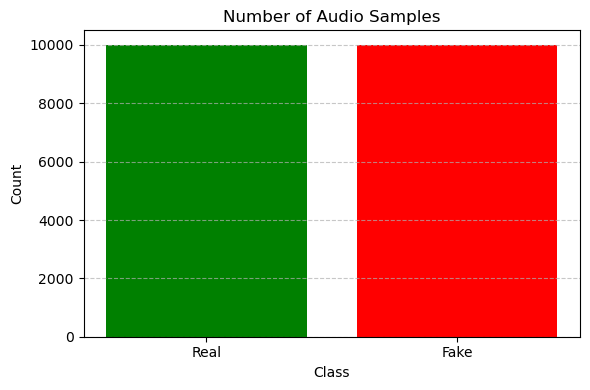

In [3]:
import matplotlib.pyplot as plt

# Count samples
real_count = len(real_data)
fake_count = len(fake_data)

# Plot
plt.figure(figsize=(6, 4))
plt.bar(['Real', 'Fake'], [real_count, fake_count], color=['green', 'red'])
plt.title('Number of Audio Samples')
plt.ylabel('Count')
plt.xlabel('Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


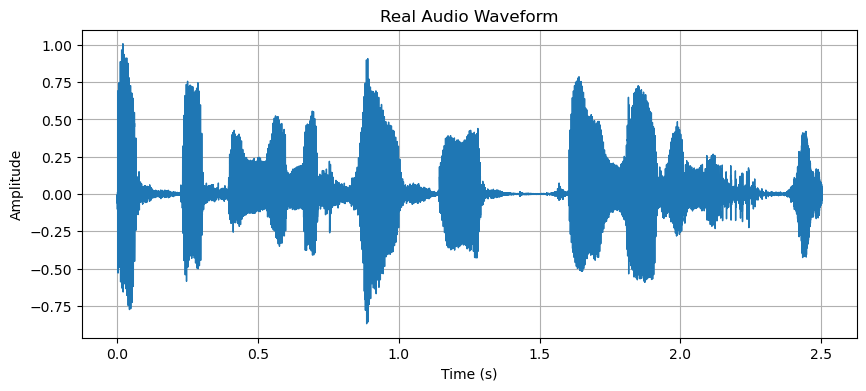

In [4]:
import matplotlib.pyplot as plt
import torchaudio

def visualize_waveform(audio_data, sr, title="Waveform"):
    """Visualizes the waveform using torchaudio."""
    plt.figure(figsize=(10, 4))
    plt.plot(torch.arange(audio_data.shape[-1]) / sr, audio_data.numpy(), linewidth=1)
    plt.title(title)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid()
    plt.show()

visualize_waveform(real_data[0], sr=22050, title="Real Audio Waveform")



In [5]:
import os

def visualize_audio_from_folders(real_folder, fake_folder):
    """Loads and visualizes waveforms of real and fake audio samples."""
    SUPPORTED_FORMATS = ('.wav', '.flac', '.mp3', '.ogg', '.m4a', '.aac', '.wma')  # ✅ Supports multiple formats
    
    # ✅ Load and visualize real data
    real_files = [f for f in os.listdir(real_folder) if f.lower().endswith(SUPPORTED_FORMATS)][:2]
    print(f"🔍 Found {len(real_files)} real audio files: {real_files}")  # ✅ Debugging
    for file_name in real_files:
        file_path = os.path.join(real_folder, file_name)
        print(f"📂 Loading real audio: {file_path}")  # ✅ Debugging
        audio_data, sr = load_audio_file(file_path)
        if audio_data is not None:
            visualize_waveform(audio_data, sr, title=f'Real: {file_name}')
        else:
            print(f"⚠️ Skipping {file_name}: No valid audio data.")

    # ✅ Load and visualize fake data
    fake_files = [f for f in os.listdir(fake_folder) if f.lower().endswith(SUPPORTED_FORMATS)][:2]
    print(f"🔍 Found {len(fake_files)} fake audio files: {fake_files}")  # ✅ Debugging
    for file_name in fake_files:
        file_path = os.path.join(fake_folder, file_name)
        print(f"📂 Loading fake audio: {file_path}")  # ✅ Debugging
        audio_data, sr = load_audio_file(file_path)
        if audio_data is not None:
            visualize_waveform(audio_data, sr, title=f'Fake: {file_name}')
        else:
            print(f"⚠️ Skipping {file_name}: No valid audio data.")


🔍 Found 2 real audio files: ['file1.wav_16k.wav_norm.wav_mono.wav_silence.wav', 'file10.wav_16k.wav_norm.wav_mono.wav_silence.wav']
📂 Loading real audio: D:/datasets/deepfake_audio/real\file1.wav_16k.wav_norm.wav_mono.wav_silence.wav


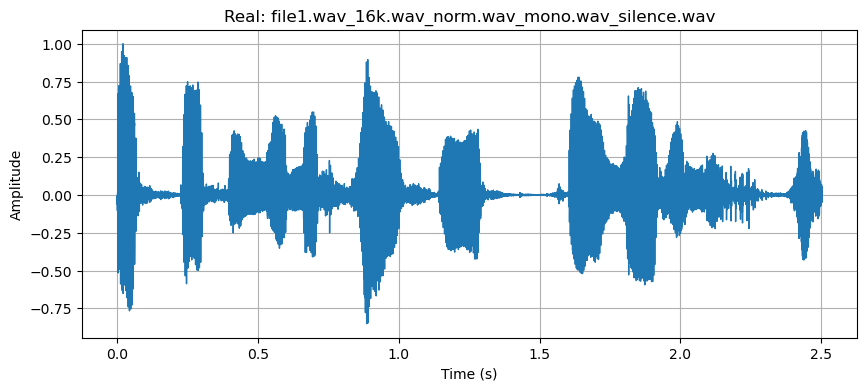

📂 Loading real audio: D:/datasets/deepfake_audio/real\file10.wav_16k.wav_norm.wav_mono.wav_silence.wav


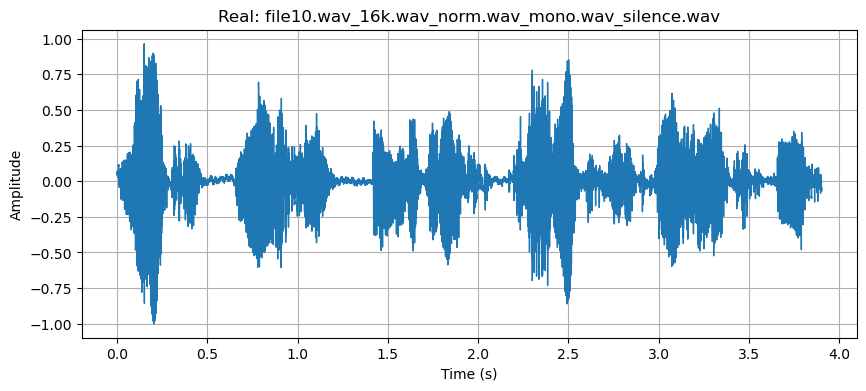

🔍 Found 2 fake audio files: ['file1.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav', 'file100.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav']
📂 Loading fake audio: D:/datasets/deepfake_audio/fake\file1.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav


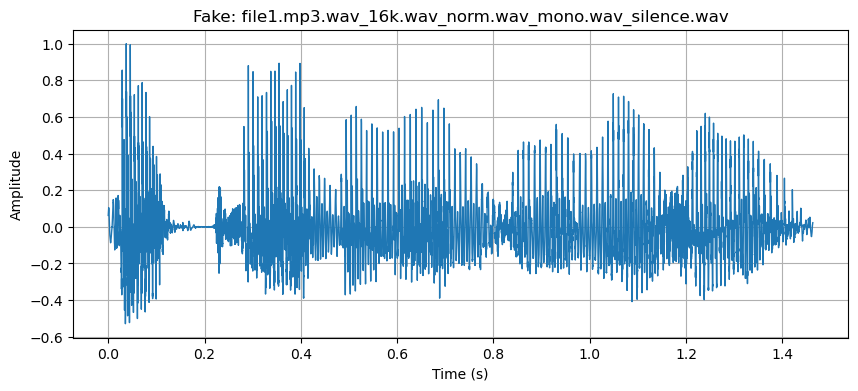

📂 Loading fake audio: D:/datasets/deepfake_audio/fake\file100.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav


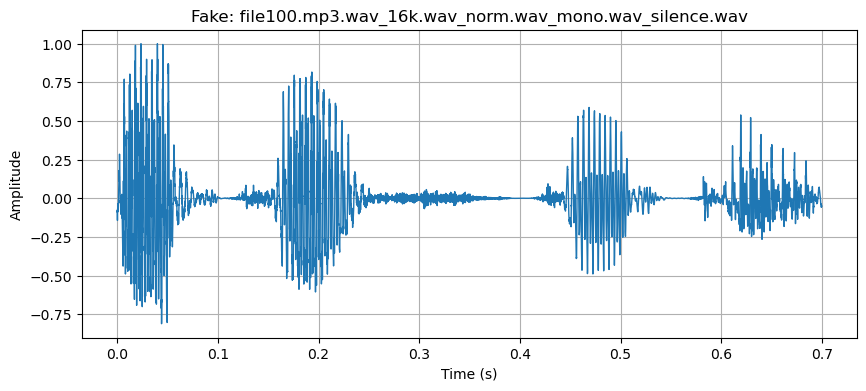

In [6]:
visualize_audio_from_folders(
    "D:/datasets/deepfake_audio/real",  
    "D:/datasets/deepfake_audio/fake"
)

In [7]:
import torchaudio.transforms as T
import torch

def extract_spectrogram(audio_data, sr):
    """Extracts a Mel spectrogram using torchaudio."""
    mel_spectrogram = T.MelSpectrogram(
        sample_rate=sr,
        n_mels=128,  # Number of mel bins
        n_fft=1024,  # FFT window size
        hop_length=512  # Hop length for better resolution
    )
    
    spectrogram = mel_spectrogram(audio_data)
    return spectrogram

def extract_spectrograms(data, sr):
    """Extracts Mel spectrograms from a list of waveforms."""
    spectrograms = [extract_spectrogram(audio, sr) for audio in data]
    return spectrograms  

# ✅ Process real and fake data
sr = 16000
real_spectrograms = extract_spectrograms(real_data, sr)
fake_spectrograms = extract_spectrograms(fake_data, sr)


In [8]:
import matplotlib.pyplot as plt
import torch

def visualize_spectrogram(spectrogram, title="Mel Spectrogram", cmap="magma"):
    """Visualizes a Mel spectrogram with customizable colormap."""
    
    plt.figure(figsize=(10, 4))

    # Convert PyTorch tensor to NumPy and apply log scaling
    if isinstance(spectrogram, torch.Tensor):
        spectrogram = spectrogram.detach().cpu().numpy()  # Convert to NumPy
        spectrogram = torch.log1p(torch.tensor(spectrogram)).numpy()  # Safe log scale

    # Plot spectrogram with selected colormap
    plt.imshow(spectrogram, aspect='auto', origin='lower', cmap=cmap)
    plt.colorbar(label="Log Power")
    plt.title(title)
    plt.xlabel("Time Frames")
    plt.ylabel("Mel Frequency Bins")
    plt.show()


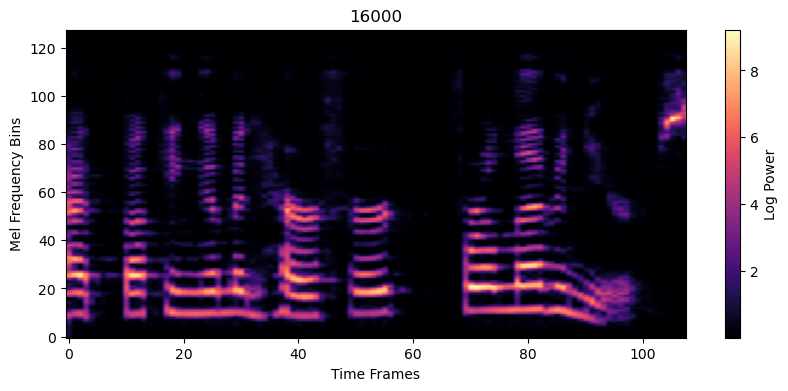

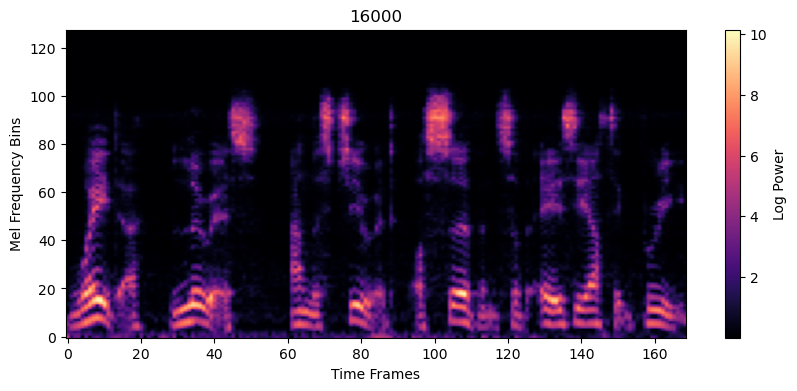

In [9]:
# Visualize first two real spectrograms
for spectrogram in real_spectrograms[:2]:
    visualize_spectrogram(spectrogram, sr)

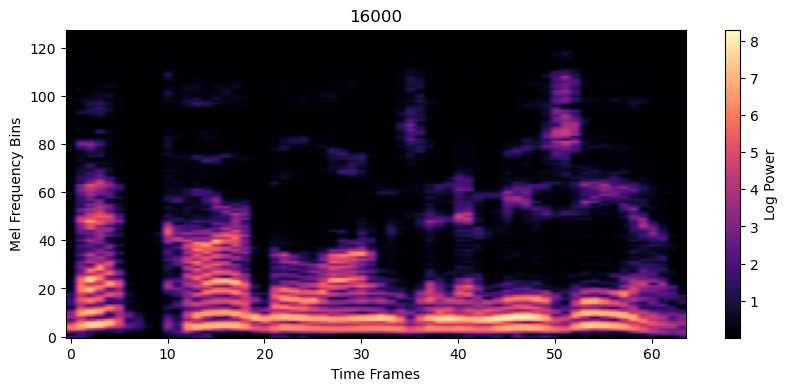

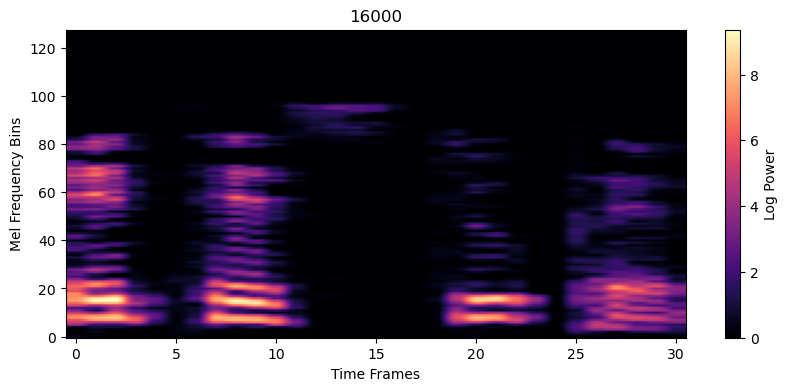

In [10]:
# Visualize first two fake spectrograms
for spectrogram in fake_spectrograms[:2]:
    visualize_spectrogram(spectrogram, sr)

In [11]:
def add_random_noise(spectrogram, noise_level=0.02):
    """Adds random Gaussian noise to spectrogram."""
    noise = np.random.normal(0, noise_level, spectrogram.shape)
    return np.clip(spectrogram + noise, 0, 1)

def augment_spectrogram(spec):
    """Applies SpecAugment + noise."""
    if isinstance(spec, np.ndarray):
        spec = torch.tensor(spec, dtype=torch.float32)

    if random.random() < 0.5:
        spec = T.FrequencyMasking(freq_mask_param=random.randint(10, 25))(spec)
    if random.random() < 0.5:
        spec = T.TimeMasking(time_mask_param=random.randint(20, 40))(spec)
    
    spec = spec.numpy()  # only convert here
    return add_random_noise(spec)

augmented_real_spectrograms = [augment_spectrogram(spec) for spec in real_spectrograms]
augmented_fake_spectrograms = [augment_spectrogram(spec) for spec in fake_spectrograms]



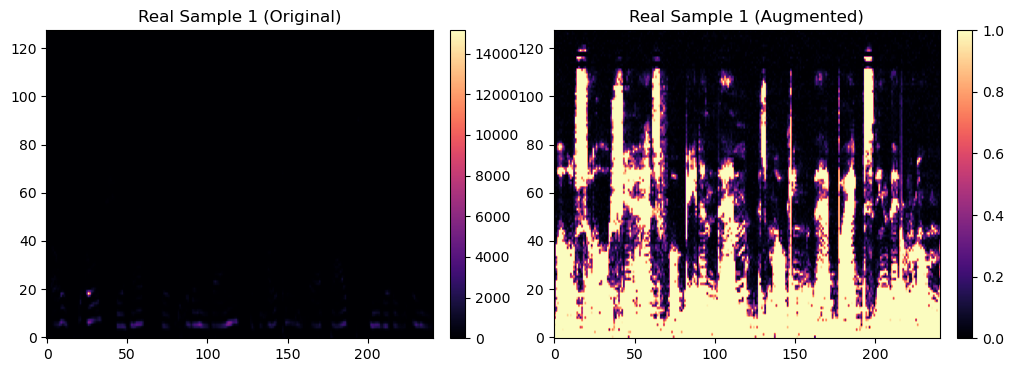

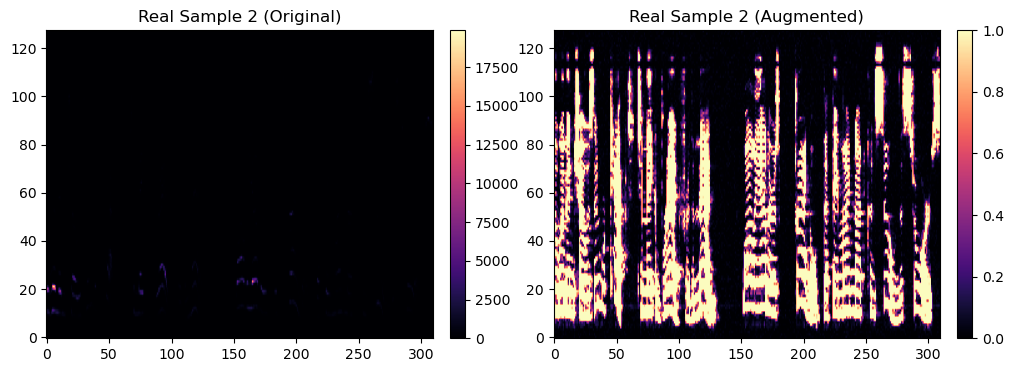

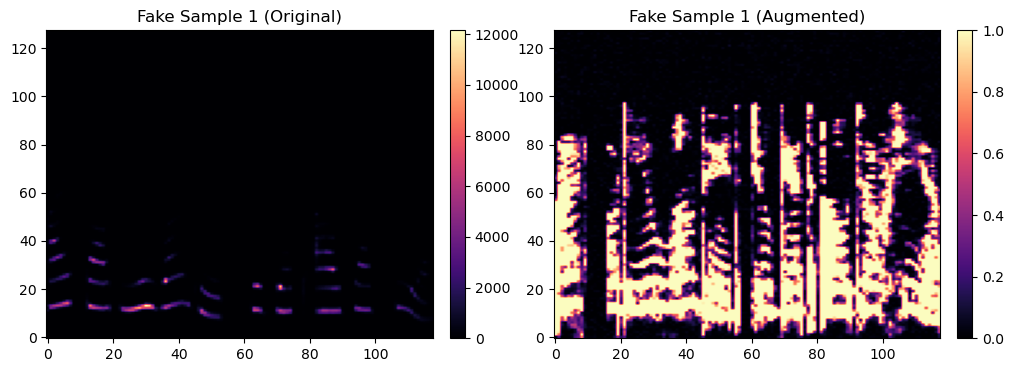

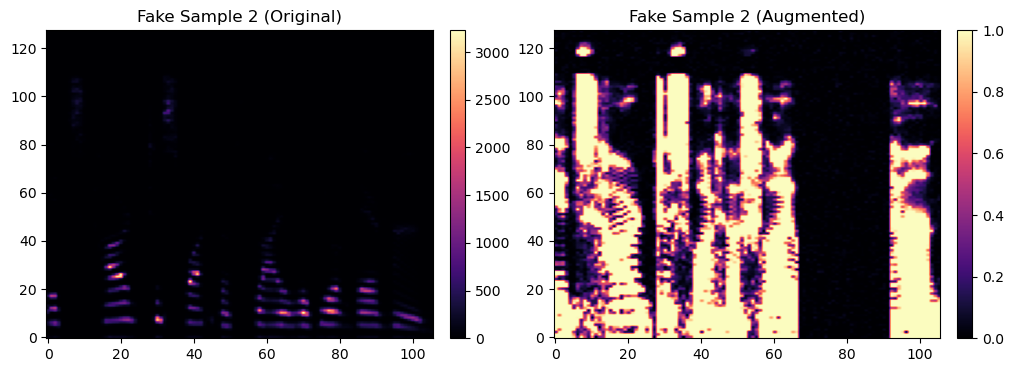

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random

# ✅ Select 2 random samples from real and fake data
sample_real_idx = random.sample(range(len(real_spectrograms)), 2)
sample_fake_idx = random.sample(range(len(fake_spectrograms)), 2)

# ✅ Extract original and augmented spectrograms
real_original_samples = [real_spectrograms[i] for i in sample_real_idx]
real_augmented_samples = [augmented_real_spectrograms[i] for i in sample_real_idx]

fake_original_samples = [fake_spectrograms[i] for i in sample_fake_idx]
fake_augmented_samples = [augmented_fake_spectrograms[i] for i in sample_fake_idx]

# ✅ Function to Convert Tensors to Numpy for Display
def tensor_to_numpy(tensor):
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.detach().cpu().numpy()  # Convert to NumPy
    if tensor.ndim == 3:  # If tensor has an extra channel dimension
        tensor = tensor.squeeze(0)
    return tensor

# ✅ Visualization Function
def plot_spectrograms(original, augmented, title_original, title_augmented):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    original_np = tensor_to_numpy(original)
    augmented_np = tensor_to_numpy(augmented)

    img1 = axes[0].imshow(original_np, aspect='auto', origin='lower', cmap='magma')
    img2 = axes[1].imshow(augmented_np, aspect='auto', origin='lower', cmap='magma')

    axes[0].set_title(title_original)
    axes[1].set_title(title_augmented)
    
    plt.colorbar(img1, ax=axes[0], fraction=0.046, pad=0.04)
    plt.colorbar(img2, ax=axes[1], fraction=0.046, pad=0.04)
    
    plt.show()

# ✅ Plot Real Samples
for i in range(2):
    plot_spectrograms(
        real_original_samples[i], real_augmented_samples[i], 
        f"Real Sample {i+1} (Original)", f"Real Sample {i+1} (Augmented)"
    )

# ✅ Plot Fake Samples
for i in range(2):
    plot_spectrograms(
        fake_original_samples[i], fake_augmented_samples[i], 
        f"Fake Sample {i+1} (Original)", f"Fake Sample {i+1} (Augmented)"
    )


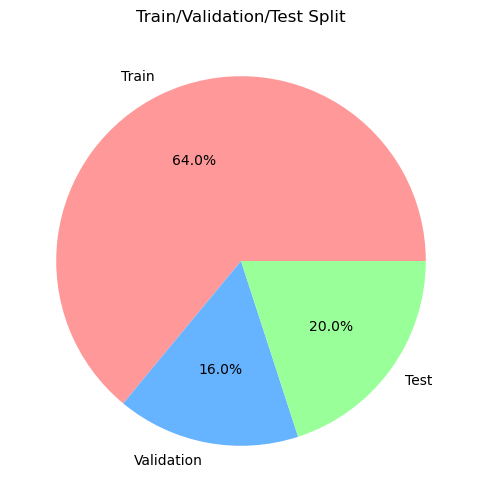

In [13]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ✅ Ensure Fixed Spectrogram Size
def process_spectrogram(spec, target_size=(128, 128)):
    """Ensures all spectrograms have a fixed size by padding/cropping."""
    if isinstance(spec, torch.Tensor):
        spec = spec.squeeze().numpy()  # Convert tensor to numpy and remove any singleton dimensions

    height, width = spec.shape  

    # Crop if too wide
    if width > target_size[1]:
        spec = spec[:, :target_size[1]]  

    # Pad if too narrow
    elif width < target_size[1]:
        pad_width = target_size[1] - width
        spec = np.pad(spec, ((0, 0), (0, pad_width)), mode='constant')

    # Resize to uniform size
    spec = cv2.resize(spec, target_size, interpolation=cv2.INTER_AREA)

    return spec


# ✅ Convert Spectrograms to NumPy Array (Without RGB Conversion)
def convert_to_numpy(spectrograms, target_size=(128, 128)):
    """Converts spectrograms to NumPy with shape (128, 128, 1) for grayscale."""
    spectrograms_np = [process_spectrogram(spec) for spec in spectrograms]
    # Keep grayscale format (no conversion to 3 channels)
    spectrograms_np = np.array(spectrograms_np, dtype=np.float32)[..., np.newaxis]
    return spectrograms_np

# ✅ Load and Process Data
real_spectrograms_np = convert_to_numpy(augmented_real_spectrograms)
fake_spectrograms_np = convert_to_numpy(augmented_fake_spectrograms)

# ✅ Balance Dataset
min_samples = min(len(real_spectrograms_np), len(fake_spectrograms_np))
real_spectrograms_np, fake_spectrograms_np = real_spectrograms_np[:min_samples], fake_spectrograms_np[:min_samples]

# ✅ Prepare Dataset for Binary Classification
X = np.vstack((real_spectrograms_np, fake_spectrograms_np))
y = np.array([1] * len(real_spectrograms_np) + [0] * len(fake_spectrograms_np))  # Binary labels


# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

# ✅ Plot Pie Chart of Data Split
split_sizes = [len(X_train), len(X_val), len(X_test)]
split_labels = ['Train', 'Validation', 'Test']
plt.figure(figsize=(6, 6))
plt.pie(split_sizes, labels=split_labels, autopct='%1.1f%%', colors=['#ff9999', '#66b3ff', '#99ff99'])
plt.title('Train/Validation/Test Split')
plt.show()


In [14]:
print("X_train shape:", X_train.shape)  # Should be (num_samples, 128, 128, 3)
print("y_train shape:", y_train.shape)


X_train shape: (12800, 128, 128, 1)
y_train shape: (12800,)


In [15]:
import numpy as np

# ✅ Check unique labels and their counts
def check_labels(name, y):
    unique_classes, class_counts = np.unique(y, return_counts=True)
    print(f"{name} Label Distribution: {dict(zip(unique_classes, class_counts))}")

# Check labels in train, validation, and test sets
check_labels("Training Set", y_train)
check_labels("Validation Set", y_val)
check_labels("Test Set", y_test)


Training Set Label Distribution: {0: 6400, 1: 6400}
Validation Set Label Distribution: {0: 1600, 1: 1600}
Test Set Label Distribution: {0: 2000, 1: 2000}


In [20]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import Input, Lambda, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
import tensorflow as tf

# Input layer for grayscale image
input_shape = (128, 128, 1)
input_layer = Input(shape=input_shape)

# Convert grayscale to RGB
rgb_layer = Lambda(lambda x: tf.image.grayscale_to_rgb(x))(input_layer)

# Load DenseNet201 base model (pretrained on ImageNet)
base_model = DenseNet201(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = True

# Freeze all layers except the last 10
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Add custom layers
x = base_model(rgb_layer)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output_layer = Dense(1, activation='sigmoid')(x)

# Final model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet201 (Functional)        │ (None, 4, 4, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,921 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,323,905 (69.90 MB)

 Trainable params: 288,321 (1.10 MB)

 Non-trainable params: 18,035,584 (68.80 MB)

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, roc_curve, confusion_matrix, classification_report

# ✅ Early Stopping to Prevent Overfitting



early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3,  
    restore_best_weights=True, 
    verbose=1
)

# ✅ Save the Best Model
checkpoint = ModelCheckpoint(
    filepath='C:/Users/user/Desktop/audio_models/DenseNet201.h5',  # Save best model to this path
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,  # Save the entire model
    verbose=1
)

# ✅ Train the Model
batch_size = 32
epochs = 15 

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8654 - loss: 0.3223
Epoch 1: val_loss improved from inf to 0.13060, saving model to C:/Users/user/Desktop/audio_models/DenseNet201.h5


400/400 ━━━━━━━━━━━━━━━━━━━━ 2434s 6s/step - accuracy: 0.8655 - loss: 0.3221 - val_accuracy: 0.9538 - val_loss: 0.1306
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9568 - loss: 0.1240
Epoch 2: val_loss improved from 0.13060 to 0.08538, saving model to C:/Users/user/Desktop/audio_models/DenseNet201.h5


400/400 ━━━━━━━━━━━━━━━━━━━━ 2462s 6s/step - accuracy: 0.9568 - loss: 0.1240 - val_accuracy: 0.9706 - val_loss: 0.0854
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9710 - loss: 0.0848
Epoch 3: val_loss improved from 0.08538 to 0.08044, saving model to C:/Users/user/Desktop/audio_models/DenseNet201.h5


400/400 ━━━━━━━━━━━━━━━━━━━━ 1138s 3s/step - accuracy: 0.9710 - loss: 0.0848 - val_accuracy: 0.9731 - val_loss: 0.0804
Epoch 4/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9725 - loss: 0.0747
Epoch 4: val_loss did not improve from 0.08044
400/400 ━━━━━━━━━━━━━━━━━━━━ 1094s 3s/step - accuracy: 0.9725 - loss: 0.0747 - val_accuracy: 0.9684 - val_loss: 0.0859
Epoch 5/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9815 - loss: 0.0521
Epoch 5: val_loss improved from 0.08044 to 0.07784, saving model to C:/Users/user/Desktop/audio_models/DenseNet201.h5


400/400 ━━━━━━━━━━━━━━━━━━━━ 962s 2s/step - accuracy: 0.9815 - loss: 0.0521 - val_accuracy: 0.9756 - val_loss: 0.0778
Epoch 6/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9883 - loss: 0.0365
Epoch 6: val_loss did not improve from 0.07784
400/400 ━━━━━━━━━━━━━━━━━━━━ 957s 2s/step - accuracy: 0.9883 - loss: 0.0365 - val_accuracy: 0.9737 - val_loss: 0.0818
Epoch 7/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9879 - loss: 0.0388
Epoch 7: val_loss improved from 0.07784 to 0.07616, saving model to C:/Users/user/Desktop/audio_models/DenseNet201.h5


400/400 ━━━━━━━━━━━━━━━━━━━━ 953s 2s/step - accuracy: 0.9879 - loss: 0.0388 - val_accuracy: 0.9753 - val_loss: 0.0762
Epoch 8/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9904 - loss: 0.0274
Epoch 8: val_loss did not improve from 0.07616
400/400 ━━━━━━━━━━━━━━━━━━━━ 1021s 2s/step - accuracy: 0.9904 - loss: 0.0274 - val_accuracy: 0.9666 - val_loss: 0.1157
Epoch 9/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9861 - loss: 0.0350
Epoch 9: val_loss did not improve from 0.07616
400/400 ━━━━━━━━━━━━━━━━━━━━ 973s 2s/step - accuracy: 0.9861 - loss: 0.0350 - val_accuracy: 0.9759 - val_loss: 0.0853
Epoch 10/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9873 - loss: 0.0361
Epoch 10: val_loss did not improve from 0.07616
400/400 ━━━━━━━━━━━━━━━━━━━━ 980s 2s/step - accuracy: 0.9873 - loss: 0.0361 - val_accuracy: 0.9750 - val_loss: 0.0911
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 7.


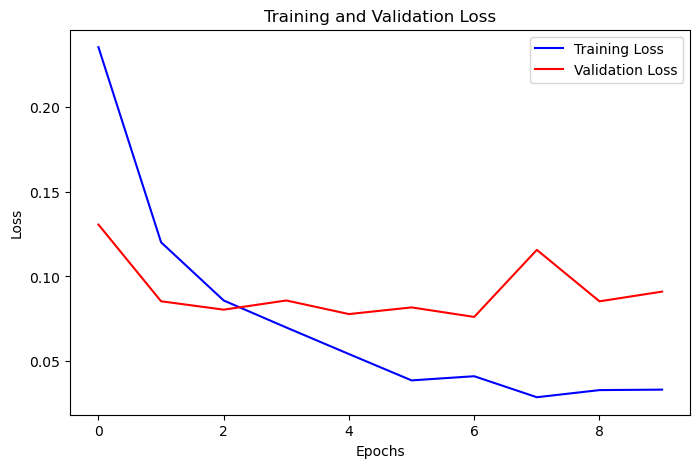

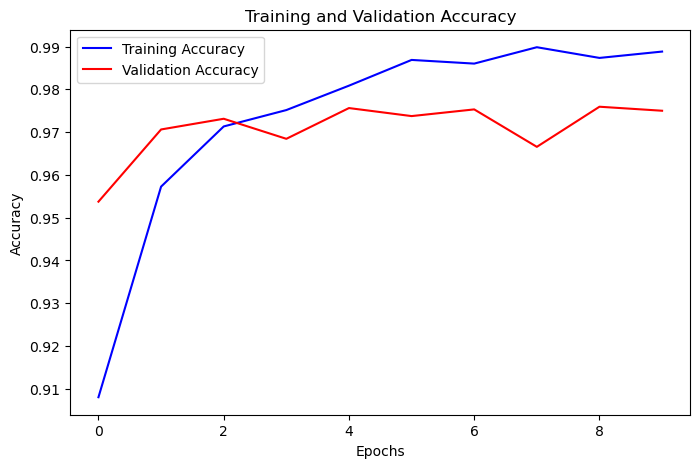

125/125 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step
Unique labels in y_test: [0 1]
Final Accuracy: 0.9715
Precision: 0.9831
Recall: 0.9595
F1-Score: 0.9712
AUC-ROC: 0.9965

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      2000
           1       0.98      0.96      0.97      2000

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



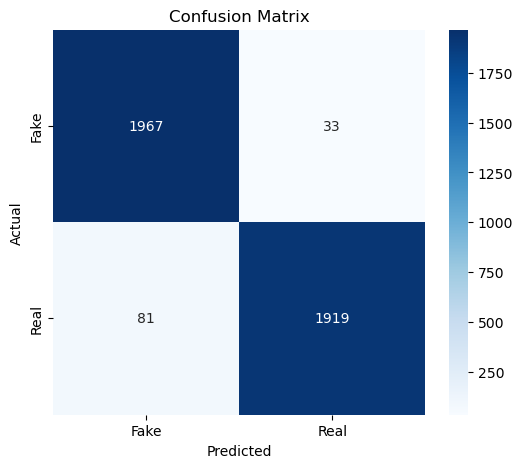

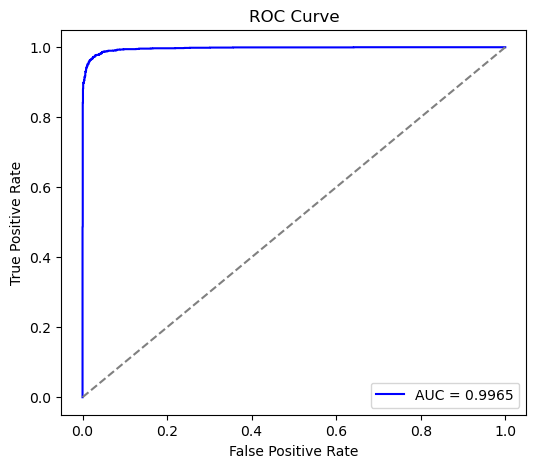

C:\Users\user\AppData\Local\Temp\ipykernel_6724\791296830.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette="viridis")


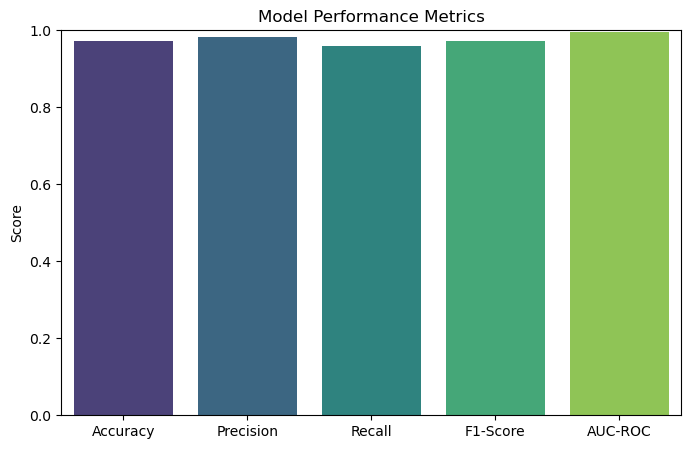

In [23]:

best_model = model  

# ✅ Plot Training and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ✅ Plot Training and Validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ✅ Make Predictions
y_pred_prob = best_model.predict(X_test).flatten()  # Ensure it's 1D
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary labels

# ✅ Convert Labels to 1D
y_test = y_test.flatten()  # Convert shape (4000, 1) → (4000,)

# ✅ Check Unique Classes
unique_classes = np.unique(y_test)
print(f"Unique labels in y_test: {unique_classes}")

# ✅ Compute Metrics
accuracy = np.mean(y_pred == y_test)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")

# ✅ Compute AUC-ROC Only if Both Classes Are Present
if len(unique_classes) > 1:
    auc_roc = roc_auc_score(y_test, y_pred_prob)
else:
    auc_roc = None  # AUC-ROC is undefined
    print("\n⚠️ Warning: AUC-ROC cannot be computed because only one class is present in y_test!")

# ✅ Print Evaluation Metrics
print(f"Final Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
if auc_roc is not None:
    print(f"AUC-ROC: {auc_roc:.4f}")

# ✅ Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ✅ Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ✅ ROC Curve (Only If Both Classes Are Present)
if auc_roc is not None:
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color="blue", label=f"AUC = {auc_roc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

# ✅ Bar Graph for Model Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [accuracy, precision, recall, f1]

if auc_roc is not None:
    metrics.append("AUC-ROC")
    values.append(auc_roc)

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=values, palette="viridis")
plt.ylim(0, 1)  # Ensure y-axis is between 0 and 

plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.show()

In [24]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# Print the test accuracy and loss
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.9698 - loss: 0.0866
Test Loss: 0.08571384102106094
Test Accuracy: 0.9714999794960022
